# Misión 3: Voz del Cliente en las Reviews

Este notebook clasifica el sentimiento de las reviews de Olist como positivo o
negativo, usando NLP. Se comparan dos modelos: Naive Bayes (Multinomial) y SVM.

Target: construido a partir de review_score, no existe una columna de sentimiento
directa.
- Positivo: review_score 4 o 5
- Negativo: review_score 1 o 2
- Neutral (3 estrellas): descartado del entrenamiento, zona ambigua que no
  aporta señal clara a una clasificación binaria

Solo se usan reviews con texto real (review_comment_message no nulo).

Tabla usada: order_reviews.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # expresiones regulares
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF: vectorizacion de texto
from sklearn.naive_bayes import MultinomialNB, ComplementNB # MultinomialNB (clasico) y ComplementNB (variante)
from sklearn.svm import LinearSVC, SVC # LinearSVC (lineal) y SVC (general)
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# data_raw: ruta
data_raw = Path("..") / "data" / "raw"

# reseñas con score y texto
reviews = pd.read_csv(data_raw / "olist_order_reviews_dataset.csv")

## Reviews con texto y etiqueta de sentimiento

Quedarse solo con reviews que tienen review_comment_message real (no nulo),
descartar las de 3 estrellas, y binarizar review_score en sentimiento
positivo/negativo.

In [2]:
# Solo columnas utiles: score y comentario
reviews_text = reviews[['review_score', 'review_comment_message']].copy()

# Descarta las que no tienen texto y solo espacios
reviews_text = reviews_text.dropna(subset=['review_comment_message'])
reviews_text = reviews_text[reviews_text['review_comment_message'].str.strip() != '']

# Descarta las 3 estrellas (zona ambigua)
reviews_text = reviews_text[reviews_text['review_score'] != 3]

# Sentimiento: >=4 positivo, resto negativo
reviews_text['sentiment'] = np.where(reviews_text['review_score'] >= 4, 'positivo', 'negativo')

print('Distribucion de sentimientos:')
# Conteo por clase
print(reviews_text['sentiment'].value_counts())
print(f'\nTotal resenas con texto (sin 3 estrellas): {len(reviews_text)}')

Distribucion de sentimientos:
sentiment
positivo    26505
negativo    10889
Name: count, dtype: int64

Total resenas con texto (sin 3 estrellas): 37394


## Normalización del texto

Función de preprocesamiento para las reviews: minúsculas, sacar urls y saltos de
línea, sacar contenidos que no sean letras (conservando tildes), y aplicar
stemming con RSLPStemmer para reducir variantes de una misma raíz. Las negaciones
se manejan aparte para no invertir el sentido de frases como "nao gostei".

In [3]:
from nltk.stem import RSLPStemmer # reduce palabras del portugues a su raiz
from nltk.corpus import stopwords # palabrabras vacias que no aportan un significado clave

stop_pt = set(stopwords.words('portuguese')) # set de stopwords

# Negaciones explicitas que se conservan
negaciones = {'nao', 'não', 'nem', 'nunca', 'jamais', 'nenhum', 'nenhuma', 'tampouco'}

stop_sin_negaciones = stop_pt - negaciones # no se filtran las negaciones 

stemmer = RSLPStemmer()

# Funcion de limpieza
def limpiar_texto(texto):
    texto = str(texto).lower()

# Quita URLs, saltos de linea y menc. de dinero
    texto = re.sub(r'http\S+|\n', ' ', texto)
    texto = re.sub(r'r\$\s?\d+[\.,]?\d*', ' ', texto)

    texto = re.sub(r'[^a-zà-ÿ]', ' ', texto)

# Filtrado stopwords y palabras <= 2 letras
    palabras = [p for p in texto.split() if p not in stop_sin_negaciones]

    palabras = [stemmer.stem(p) for p in palabras if len(p) > 2]

    return ' '.join(palabras)

# Limpieza a toda la columna y descarte de textos vacios
reviews_text['texto_limpio'] = reviews_text['review_comment_message'].apply(limpiar_texto)
reviews_text = reviews_text[reviews_text['texto_limpio'].str.len() > 0]

print(f'Reviews tras limpieza: {len(reviews_text)}')
reviews_text[['review_comment_message', 'texto_limpio']].head()

Reviews tras limpieza: 37057


,review_comment_message,texto_limpio
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt entreg ant praz


## Reparto estratificado train/test

80% entrenamiento / 20% test, con estratificación por la clase de sentimiento
para mantener la proporción de clases en ambos conjuntos.

In [4]:
X_text = reviews_text['texto_limpio']
y_text = reviews_text['sentiment']

# 80/20 con stratify
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_text, y_text, test_size=0.2, random_state=42, stratify=y_text
)

print(f'Train: {len(X_train_txt)} | Test: {len(X_test_txt)}')

Train: 29645 | Test: 7412


## Combate: Bayes vs SVM

Usar ComplementNB (variante de Naive Bayes para clases desbalanceadas) y
LinearSVC (SVM lineal, estándar en NLP por su costo en alta dimensionalidad).

In [5]:
# Pipeline Naive Bayes
pipe_nb = Pipeline([
    # texto a una matriz num. de importancia, 5000 palabras mas frecuentes y que aparezcan en 3 docs al menos, y analiza palbra por palabra
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 1))),
    ('clf', ComplementNB()) # clasif. de datos desbalanceados, debido a que x palabras aparecen x veces que probabilidad hay de que sea una review neg.
])

# Entrena y prediccion sobre test
pipe_nb.fit(X_train_txt, y_train_txt)
y_pred_nb = pipe_nb.predict(X_test_txt)

# Titulo del reporte NB
print('--- NAIVE BAYES (ComplementNB) ---')
print(classification_report(y_test_txt, y_pred_nb))

# Pipeline SVM
pipe_svm = Pipeline([

    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3,
                              ngram_range=(1, 1))),
# LinearSVC con clases balanceadas
    ('clf', LinearSVC(class_weight='balanced', random_state=42)) #clasif. balanceada, encuentra un coef. para cada palabra y ve como seinclina la balanza segun sean positivos o negativ9os
])

# Entrena y predice sobre test
pipe_svm.fit(X_train_txt, y_train_txt)
y_pred_svm = pipe_svm.predict(X_test_txt)

# Titulo del reporte SVM
print('--- SVM (LinearSVC) ---')
# Reporte de precision, recall, f1
print(classification_report(y_test_txt, y_pred_svm))

--- NAIVE BAYES (ComplementNB) ---
              precision    recall  f1-score   support

    negativo       0.76      0.94      0.84      2174
    positivo       0.97      0.88      0.92      5238

    accuracy                           0.90      7412
   macro avg       0.87      0.91      0.88      7412
weighted avg       0.91      0.90      0.90      7412



--- SVM (LinearSVC) ---
              precision    recall  f1-score   support

    negativo       0.82      0.92      0.86      2174
    positivo       0.96      0.92      0.94      5238

    accuracy                           0.92      7412
   macro avg       0.89      0.92      0.90      7412
weighted avg       0.92      0.92      0.92      7412



## Matrices de confusión por modelo

Visualizar los aciertos y errores por clase de cada modelo.

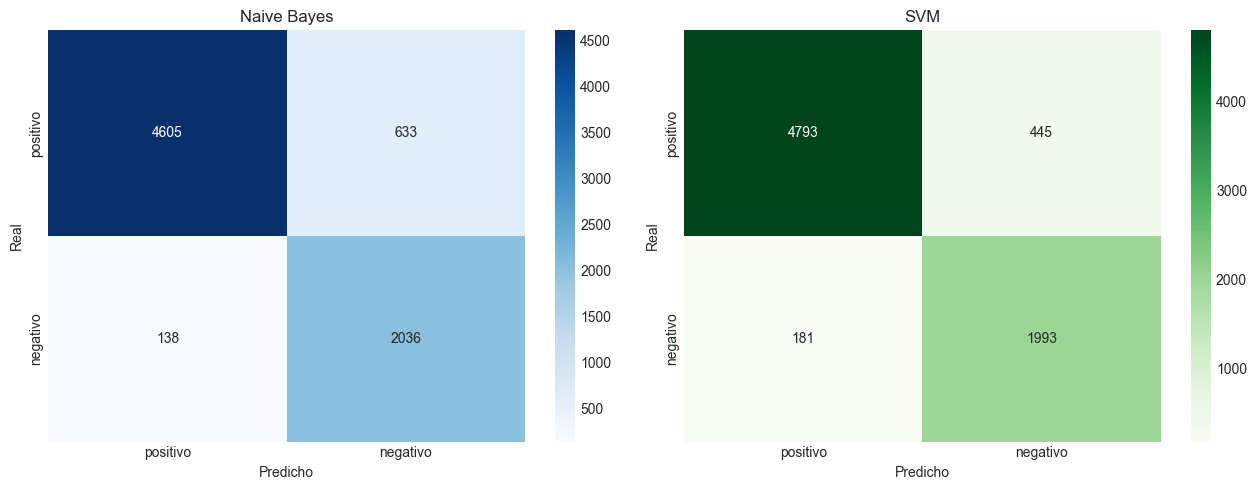

In [6]:
# Orden de las clases para la matriz
labels = ['positivo', 'negativo']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusion de NB
cm_nb = confusion_matrix(y_test_txt, y_pred_nb, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Naive Bayes')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Matriz de confusion de SVM
cm_svm = confusion_matrix(y_test_txt, y_pred_svm, labels=labels)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('SVM')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Ajusta y muestra
plt.tight_layout()
plt.show()

### Hallazgos

- **El error más caro es negativo → positivo** (una queja no detectada): Naive Bayes lo minimiza (recall 0.94) pero dispara muchas falsas alarmas (precisión 0.76).
- **Conviene LinearSVC:** recall 0.92 casi igual, menos falsas alarmas (precisión 0.82) y mejor accuracy (0.92 vs 0.90).


## Validación cruzada de ambos


In [7]:
# CV 5 pliegues NB y SVM
cv_nb = cross_val_score(pipe_nb, X_text, y_text, cv=5, scoring='accuracy') # accuracy como metrica de evaluacion
cv_svm = cross_val_score(pipe_svm, X_text, y_text, cv=5, scoring='accuracy')

# Promedio de Accuracy +/- desvio de NB y SVM
print(f'Naive Bayes CV Accuracy: {cv_nb.mean():.3f} +/- {cv_nb.std():.3f}')
print(f'SVM CV Accuracy:         {cv_svm.mean():.3f} +/- {cv_svm.std():.3f}')

Naive Bayes CV Accuracy: 0.898 +/- 0.002
SVM CV Accuracy:         0.918 +/- 0.002


## Términos que delatan cada sentimiento

Extraer los términos con mayor peso en cada clase, para validar que el modelo
aprendió marcadores de sentimiento coherentes con el negocio.

In [8]:
# Extrae los terminos mas decisivos por clase
def palabras_clave(pipeline, top_n=10):
# Acceso al vectorizador y clasif. dentro del pipeline
    tfidf = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']

# Lista completa de las palabras ordenadas
    features = tfidf.get_feature_names_out()

    if hasattr(clf, 'coef_'):
    # Caso binario: una fila pos. y neg
        if clf.coef_.shape[0] == 1:

            pesos = clf.coef_[0] #extrae los coef. de esa fila

            idx_pos = np.argsort(pesos)[-top_n:] #ordena los pesos de mayor a menor 
            idx_neg = np.argsort(pesos)[:top_n] # lo pesos mas neg. los empuja a la otra clase

# Clase a la que corresponden los pesos positivos y negativos
            print(f'{clf.classes_[1]}: {', '.join(features[j] for j in idx_pos)}')
            print(f'{clf.classes_[0]}: {', '.join(features[j] for j in idx_neg)}')

        else: # Caso multiclase (si algun dia)
            for i, clase in enumerate(clf.classes_):
                idx = np.argsort(clf.coef_[i])[-top_n:]
                palabras = [features[j] for j in idx]
                print(f'{clase}: {', '.join(palabras)}')

# Rama para Naive Bayes (feature_log_prob_)
    elif hasattr(clf, 'feature_log_prob_'):
        for i, clase in enumerate(clf.classes_):
            idx = clf.feature_log_prob_[i].argsort()[-top_n:] # indices con mayor probabilidad log.
            palabras = [features[j] for j in idx]
            print(f'{clase}: {', '.join(palabras)}') #palabras mas representativas

# Ejecuta con SVM
print('--- SVM: palabras clave ---')
palabras_clave(pipe_svm)
# Ejecuta con Naive Bayes
print('\n--- Naive Bayes: palabras clave ---')
palabras_clave(pipe_nb)

--- SVM: palabras clave ---
positivo: lind, proteg, benefíci, show, perfeit, ótim, rápid, ame, atenci, fácil
negativo: não, péss, pi, esquerd, falsific, incomplet, insatisfeit, urg, inferi, pess

--- Naive Bayes: palabras clave ---
negativo: micr, louç, mecan, lua, xper, vouch, matiz, mangu, maqui, mach
positivo: paralis, mut, muy, namor, otin, youtub, vlw, adoreiii, adquer, normal


## Limitaciones y decisiones metodológicas

- **¿Qué se descartó y por qué?** Las reviews de 3 estrellas (8.7% de las que tienen texto) no se
  usan en el entrenamiento. Es una franja ambigua: quien puntúa 3 declaró una experiencia media,
  que ni reclamó ni celebró. Si la forzamos a "positivo" o "negativo" estaríamos etiquetando
  ruido, y el modelo aprendería patrones de textos neutros como si fueran extremos.
- **Qué se pierde a cambio:** el modelo no tiene categoría "neutro". En producción, una review de
  3 estrellas caerá del lado positivo la mayoría de las veces. Para la operación (detectar quejas
  temprano) el costo es bajo, porque el recall sobre la clase negativa se mantiene alto: 0.92 en
  SVM y 0.94 en Naive Bayes.
- **Cómo seguir:** la vía natural es una arquitectura de 3 clases (positivo / neutro / negativo)
  que incorpore formalmente el 3 estrellas, sumando bigramas al vectorizador para no perder
  negaciones compuestas como "não chegou ainda".


## Conclusiones

- **LinearSVC es el modelo a usar:** accuracy 0.92, detecta el 92% de las quejas y dispara menos
  falsas alarmas que Naive Bayes (precisión negativa 0.82 vs 0.76).
- **El valor no es acertar la mayoría positiva, sino no perder quejas** — por eso el recall de la
  clase negativa manda.
- **El 3 estrellas queda fuera (8.7% del texto):** es una franja ambigua que contaminaría las
  etiquetas; a cambio, el modelo no tiene clase "neutro".
- **Para Olist:** clasificar las reviews en tiempo real para disparar tickets de retención apenas
  entre una queja, antes de que dañe la reputación pública.
